In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import sys
from pathlib import Path
import jax as jx
import time

ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm


sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp



riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

In [2]:
data = 'lores'
XXX = 2
!riesling op-nufft {data}.h5 nufft.h5 -v2


[13:05:11] [op-nufft] Welcome to RIESLING
[13:05:11] [H5    ] Opened lores.h5 for reading id 72057594037927936
[13:05:11] [Traj  ] 3D Samples 37 Traces 16127 Matrix [42, 42, 42] FOV [252.00, 252.00, 252.00]
[13:05:11] [HD5   ] Opened nufft.h5 for writing id 72057594037927937
[13:05:12] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[13:05:12] [Kernel] Width 4 Scale 1.892995e-09
[13:05:12] [Traj  ] Nominal FOV, matrix [42, 42, 42]
[13:05:12] [Traj  ] Nominal matrix [42, 42, 42] grid matrix [54, 54, 54] over-sampling [1.29, 1.29, 1.29]
[13:05:12] [Traj  ] 596699 valid, 0 invalid, 0 outside
[13:05:12] [Traj  ] Nominal FOV, matrix [42, 42, 42]
[13:05:12] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[13:05:12] [Kernel] Width 4 Scale 1.892995e-09
[13:05:12] [Apodiz] Shape [42, 42, 42] Grid shape [54, 54, 54] Scale 272.1911
[13:05:12] [NUFFT ] ishape [42, 42, 42, 1, 44] oshape [44, 37, 16127] grid [54, 54, 54, 1, 44]
[13:05:12] [Precon] λ 0.000 pow 1.000
[13:05:12] [Precon] Starti

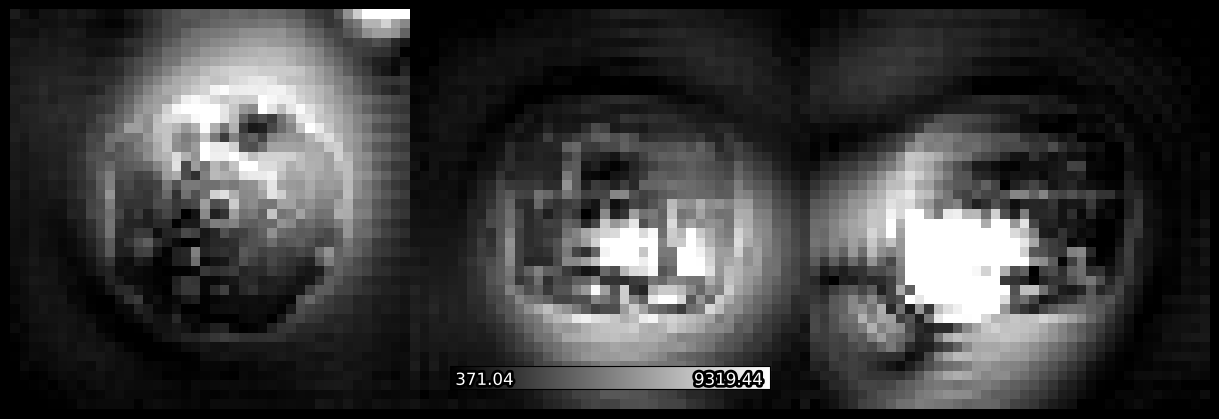

In [3]:
rlp.plot.planes('nufft.h5')

In [5]:
G = 3
R = 10
L = 5*10**-5
W = 5

!riesling zin nufft.h5 nufftz.h5 --zin-gap={G} --zin-kw={W} --zin-cal=31 --als-rank={R} --als-lambda={L} --als-its=32 -v2


[13:06:14] [zin   ] Welcome to RIESLING
[13:06:14] [H5    ] Opened nufft.h5 for reading id 72057594037927936
[13:06:14] [HD5   ] Opened nufftz.h5 for writing id 72057594037927937
[13:06:14] [ZIN   ] Infilling gap 3 calibration size 31
[13:06:14] [Lift  ] ishape [31, 31, 31, 1, 44, 1] oshape [5, 5, 5, 1, 44, 1, 19683]
[13:06:14] [ALS   ] |X| 5.10E+07 R 10 λ 5.00E-05 Maximum Iterations 32
[13:06:15] [ALS   ] 00 |ABt| 9.98E+05
[13:06:15] [ALS   ] 01 |ABt| 2.56E+07
[13:06:16] [ALS   ] 02 |ABt| 3.18E+07
[13:06:16] [ALS   ] 03 |ABt| 3.45E+07
[13:06:16] [ALS   ] 04 |ABt| 3.63E+07
[13:06:16] [ALS   ] 05 |ABt| 3.75E+07
[13:06:16] [ALS   ] 06 |ABt| 3.85E+07
[13:06:17] [ALS   ] 07 |ABt| 3.93E+07
[13:06:17] [ALS   ] 08 |ABt| 4.00E+07
[13:06:17] [ALS   ] 09 |ABt| 4.06E+07
[13:06:17] [ALS   ] 10 |ABt| 4.12E+07
[13:06:17] [ALS   ] 11 |ABt| 4.17E+07
[13:06:18] [ALS   ] 12 |ABt| 4.21E+07
[13:06:18] [ALS   ] 13 |ABt| 4.26E+07
[13:06:18] [ALS   ] 14 |ABt| 4.30E+07
[13:06:18] [ALS   ] 15 |ABt| 4.33E+07
[1

In [6]:
!riesling rss nufftz.h5 nufftz-rss.h5 --dim=4 -v2



[13:06:40] [rss   ] Welcome to RIESLING
[13:06:40] [H5    ] Opened nufftz.h5 for reading id 72057594037927936
[13:06:40] [HD5   ] Opened nufftz-rss.h5 for writing id 72057594037927937
[13:06:40] [rss   ] Finished


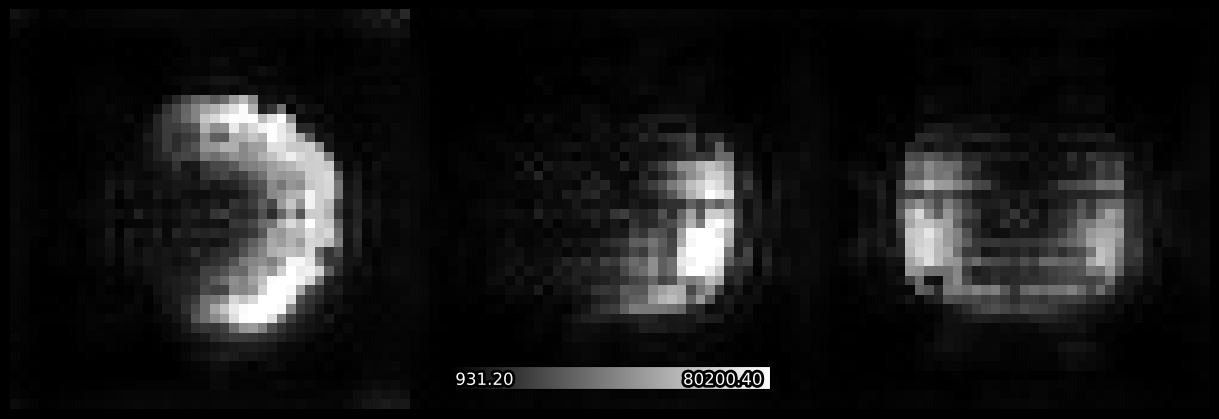

In [10]:
rlp.plot.planes('nufftz-rss.h5')